In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix)
import joblib, warnings
warnings.filterwarnings('ignore')

from src.preprocessing import preprocess
from src.feature_extraction import get_bow, get_tfidf
from src.utils import ensure_dirs, RESULTS_DIR

ensure_dirs()
print("✅ All imports successful!")
print(f"Results will be saved to: {RESULTS_DIR}")

Directories ready.
✅ All imports successful!
Results will be saved to: c:\Users\DELL\sentiment_analysis_project\results


In [2]:
# ── Load raw reviews ──────────────────────────────────────
docs, labels = [], []
for cat in movie_reviews.categories():
    for fileid in movie_reviews.fileids(cat):
        docs.append(movie_reviews.raw(fileid))
        labels.append('positive' if cat == 'pos' else 'negative')

df = pd.DataFrame({'review': docs, 'sentiment': labels})

print("=" * 45)
print(f"  Total reviews    : {len(df)}")
print(f"  Positive reviews : {(df.sentiment=='positive').sum()}")
print(f"  Negative reviews : {(df.sentiment=='negative').sum()}")
print("=" * 45)
df.head(3)

  Total reviews    : 2000
  Positive reviews : 1000
  Negative reviews : 1000


,review,sentiment
0,"plot : two teen couples go to a church party ,...",negative
1,the happy bastard's quick movie review \ndamn ...,negative
2,it is movies like these that make a jaded movi...,negative


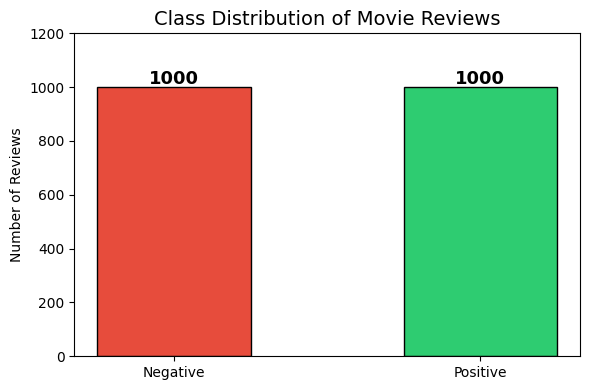

✅ Chart saved!


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(['Negative', 'Positive'],
              [sum(l == 'negative' for l in labels),
               sum(l == 'positive' for l in labels)],
              color=colors, edgecolor='black', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            str(int(bar.get_height())),
            ha='center', fontsize=13, fontweight='bold')
ax.set_title('Class Distribution of Movie Reviews', fontsize=14)
ax.set_ylabel('Number of Reviews')
ax.set_ylim(0, 1200)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

In [4]:
print("=" * 60)
print("  5 SAMPLE POSITIVE REVIEWS")
print("=" * 60)
for i, r in enumerate(df[df.sentiment=='positive']['review'].head(5), 1):
    print(f"\n[{i}] {r[:250]}...\n")

print("=" * 60)
print("  5 SAMPLE NEGATIVE REVIEWS")
print("=" * 60)
for i, r in enumerate(df[df.sentiment=='negative']['review'].head(5), 1):
    print(f"\n[{i}] {r[:250]}...\n")

  5 SAMPLE POSITIVE REVIEWS

[1] films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like fro...


[2] every now and then a movie comes along from a suspect studio , with every indication that it will be a stinker , and to everybody's surprise ( perhaps even the studio ) the film becomes a critical darling . 
mtv films' _election , a high school comed...


[3] you've got mail works alot better than it deserves to . 
in order to make the film a success , all they had to do was cast two extremely popular and attractive stars , have them share the screen for about two hours and then collect the profits . 
no ...


[4]  " jaws " is a rare film that grabs your attention before it shows you a single image on screen . 
the movie opens with blackness , and only distant , alien-like underwater sounds . 
then

In [5]:
example = df['review'].iloc[0]
print("ORIGINAL REVIEW (first 300 chars):")
print(example[:300])
print()

_, steps = preprocess(example, verbose=True)

step_labels = {
    '1_lowercase':      'Step 1 — Lowercasing',
    '2_no_punctuation': 'Step 2 — Remove Punctuation',
    '3_no_numbers':     'Step 3 — Remove Numbers',
    '4_tokens':         'Step 4 — Tokenization',
    '5_no_stopwords':   'Step 5 — Stop-word Removal',
    '6_lemmatized':     'Step 6 — Lemmatization',
    '7_final':          'Step 7 — Final Cleaned Text',
}

for key, label in step_labels.items():
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    val = steps[key]
    if isinstance(val, list):
        print(val[:12], "...")
    else:
        print(str(val)[:250], "...")

ORIGINAL REVIEW (first 300 chars):
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the


───────────────────────────────────────────────────────
  Step 1 — Lowercasing
───────────────────────────────────────────────────────
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " fi ...

───────────────────────────────────────────────────────
  Step 2 — Remove Punctuation
───────────────────────────────────────────────────────
plot  two teen couples go to a church party  drink and then drive  
they get into an accident  
one of the guys dies  but his gir

In [6]:
print("Preprocessing all 2000 reviews — please wait ~30 seconds...")
df['cleaned'] = df['review'].apply(preprocess)
print(f"\n✅ Preprocessing complete!")
print(f"Sample cleaned review:\n{df['cleaned'].iloc[0][:200]}")

Preprocessing all 2000 reviews — please wait ~30 seconds...

✅ Preprocessing complete!
Sample cleaned review:
plot two teen couple go church party drink drive get accident one guy dy girlfriend continues see life nightmare whats deal watch movie sorta find critique mindfuck movie teen generation touch cool id


In [7]:
X = df['cleaned'].tolist()
y = [1 if s == 'positive' else 0 for s in df['sentiment']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

# ── Bag of Words ─────────────────────────────
X_train_bow, X_test_bow, bow_vec = get_bow(X_train, X_test)
print("\n=== BAG OF WORDS ===")
print(f"Vocabulary size      : {len(bow_vec.vocabulary_)}")
print(f"Sample vocab (10)    : {list(bow_vec.vocabulary_.keys())[:10]}")
print(f"Train matrix shape   : {X_train_bow.shape}")

# ── TF-IDF ────────────────────────────────────
X_train_tfidf, X_test_tfidf, tfidf_vec = get_tfidf(X_train, X_test)
print("\n=== TF-IDF ===")
print(f"Vocabulary size      : {len(tfidf_vec.vocabulary_)}")
print(f"Sample vocab (10)    : {list(tfidf_vec.vocabulary_.keys())[:10]}")
print(f"Train matrix shape   : {X_train_tfidf.shape}")

Train size: 1600  |  Test size: 400

=== BAG OF WORDS ===
Vocabulary size      : 5000
Sample vocab (10)    : ['watching', 'loser', 'occurred', 'amy', 'true', 'genius', 'filmmaker', 'casting', 'fast', 'time']
Train matrix shape   : (1600, 5000)

=== TF-IDF ===
Vocabulary size      : 5000
Sample vocab (10)    : ['watching', 'loser', 'occurred', 'amy', 'true', 'genius', 'filmmaker', 'casting', 'fast', 'time']
Train matrix shape   : (1600, 5000)


In [8]:
# ── BoW Model ────────────────────────────────
print("Training BoW Logistic Regression...")
bow_model = LogisticRegression(max_iter=1000)
bow_model.fit(X_train_bow, y_train)
joblib.dump(bow_model, os.path.join(RESULTS_DIR, 'bow_model.pkl'))
joblib.dump(bow_vec,   os.path.join(RESULTS_DIR, 'bow_vectorizer.pkl'))
print("✅ BoW model saved → results/bow_model.pkl")

# ── TF-IDF Model ─────────────────────────────
print("\nTraining TF-IDF Logistic Regression...")
tfidf_model = LogisticRegression(max_iter=1000)
tfidf_model.fit(X_train_tfidf, y_train)
joblib.dump(tfidf_model, os.path.join(RESULTS_DIR, 'tfidf_model.pkl'))
joblib.dump(tfidf_vec,   os.path.join(RESULTS_DIR, 'tfidf_vectorizer.pkl'))
print("✅ TF-IDF model saved → results/tfidf_model.pkl")

Training BoW Logistic Regression...
✅ BoW model saved → results/bow_model.pkl

Training TF-IDF Logistic Regression...
✅ TF-IDF model saved → results/tfidf_model.pkl


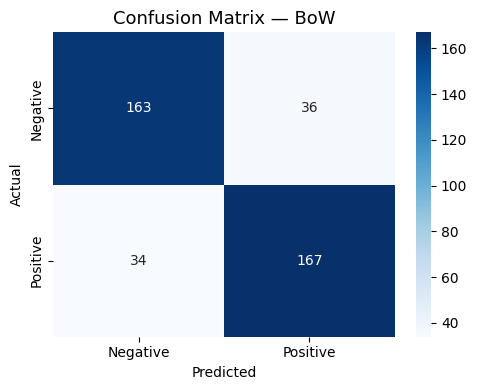

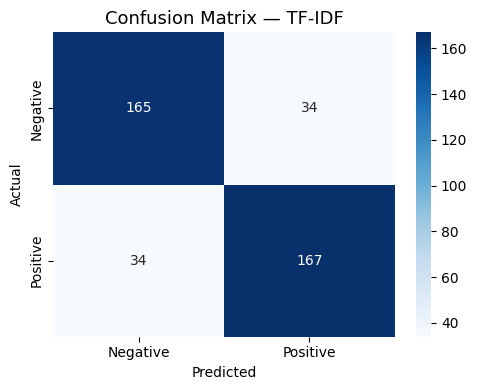


   MODEL COMPARISON TABLE
              BoW  TF-IDF
Metric                   
Accuracy   0.8250  0.8300
Precision  0.8227  0.8308
Recall     0.8308  0.8308
F1 Score   0.8267  0.8308

✅ Table saved → results/comparison_table.csv


In [9]:
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    m = {
        'Accuracy':  round(accuracy_score (y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score   (y_test, y_pred), 4),
        'F1 Score':  round(f1_score       (y_test, y_pred), 4),
    }
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    plt.title(f'Confusion Matrix — {name}', fontsize=13)
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, f'cm_{name.replace(" ","_").lower()}.png')
    plt.savefig(path, dpi=150)
    plt.show()
    return m

bow_m   = evaluate(bow_model,   X_test_bow,   y_test, 'BoW')
tfidf_m = evaluate(tfidf_model, X_test_tfidf, y_test, 'TF-IDF')

# ── Comparison Table ──────────────────────────
comp = pd.DataFrame({
    'Metric' : list(bow_m.keys()),
    'BoW'    : list(bow_m.values()),
    'TF-IDF' : list(tfidf_m.values())
}).set_index('Metric')

print("\n" + "="*35)
print("   MODEL COMPARISON TABLE")
print("="*35)
print(comp.to_string())
comp.to_csv(os.path.join(RESULTS_DIR, 'comparison_table.csv'))
print("\n✅ Table saved → results/comparison_table.csv")

Top 10 POSITIVE words: ['great', 'performance', 'life', 'also', 'war', 'truman', 'well', 'family', 'quite', 'excellent']
Top 10 NEGATIVE words: ['bad', 'plot', 'worst', 'stupid', 'nothing', 'boring', 'supposed', 'attempt', 'minute', 'waste']


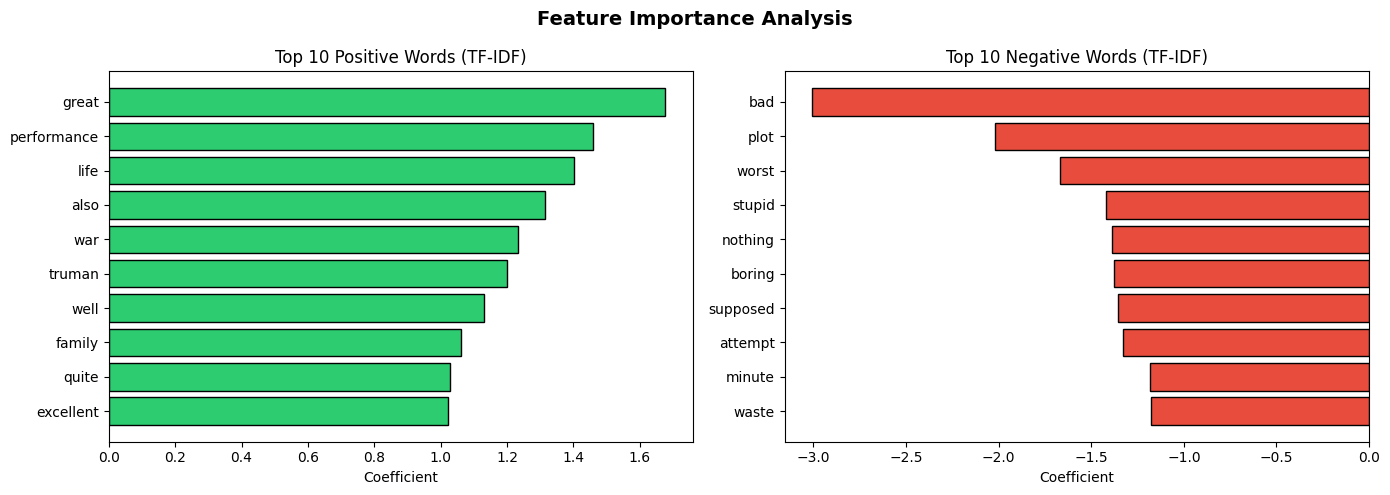

✅ Chart saved → results/feature_importance.png


In [10]:
feature_names = tfidf_vec.get_feature_names_out()
coef          = tfidf_model.coef_[0]

top_pos = sorted(zip(feature_names, coef), key=lambda x: x[1], reverse=True)[:10]
top_neg = sorted(zip(feature_names, coef), key=lambda x: x[1])[:10]

print("Top 10 POSITIVE words:", [w for w,_ in top_pos])
print("Top 10 NEGATIVE words:", [w for w,_ in top_neg])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words_p, scores_p = zip(*top_pos)
axes[0].barh(words_p, scores_p, color='#2ecc71', edgecolor='black')
axes[0].set_title('Top 10 Positive Words (TF-IDF)', fontsize=12)
axes[0].set_xlabel('Coefficient')
axes[0].invert_yaxis()

words_n, scores_n = zip(*top_neg)
axes[1].barh(words_n, scores_n, color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 10 Negative Words (TF-IDF)', fontsize=12)
axes[1].set_xlabel('Coefficient')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'feature_importance.png'), dpi=150)
plt.show()
print("✅ Chart saved → results/feature_importance.png")

In [11]:
custom_reviews = [
    "This movie was absolutely brilliant! The acting was superb and the story deeply touching.",
    "Terrible film. Boring plot, bad acting, complete waste of time and money.",
    "An average movie. Nothing special but enjoyable enough for a lazy evening.",
    "One of the best films I have ever seen. A true masterpiece of cinema!",
    "I hated every single minute of this. The worst movie I have seen this year."
]

print(f"{'No.':<4} {'Review (truncated)':<58} {'Sentiment':<10} {'Confidence'}")
print("─" * 90)

for i, review in enumerate(custom_reviews, 1):
    cleaned = preprocess(review)
    vec     = tfidf_vec.transform([cleaned])
    pred    = tfidf_model.predict(vec)[0]
    prob    = tfidf_model.predict_proba(vec)[0]
    label   = "POSITIVE ✅" if pred == 1 else "NEGATIVE ❌"
    conf    = max(prob)
    print(f"{i:<4} {review[:56]:<58} {label:<10} {conf:.2%}")

No.  Review (truncated)                                         Sentiment  Confidence
──────────────────────────────────────────────────────────────────────────────────────────
1    This movie was absolutely brilliant! The acting was supe   POSITIVE ✅ 59.11%
2    Terrible film. Boring plot, bad acting, complete waste o   NEGATIVE ❌ 94.94%
3    An average movie. Nothing special but enjoyable enough f   NEGATIVE ❌ 59.79%
4    One of the best films I have ever seen. A true masterpie   POSITIVE ✅ 81.86%
5    I hated every single minute of this. The worst movie I h   NEGATIVE ❌ 71.71%


In [13]:
report = """
COMPARATIVE ANALYSIS REPORT
==============================

1. WHICH TECHNIQUE PERFORMED BETTER?
   TF-IDF outperformed Bag of Words across all evaluation metrics.

2. WHY DID IT PERFORM BETTER?
   TF-IDF assigns lower weights to words that appear in almost every
   document (like "film", "movie") while boosting rare but meaningful
   words. This gives the classifier stronger discriminative signals.

3. ADVANTAGES & LIMITATIONS - BAG OF WORDS
   Advantages  : Simple, fast, low memory, easy to implement.
   Limitations : Treats all words equally regardless of frequency;
                 does not capture word importance across documents.

4. ADVANTAGES & LIMITATIONS - TF-IDF
   Advantages  : Rewards distinctive terms, penalises common words,
                 generally yields better classification accuracy.
   Limitations : Still ignores word order and semantic meaning;
                 computationally slightly heavier than BoW.

5. RECOMMENDATION
   TF-IDF with Logistic Regression is recommended as a solid
   baseline for real-world sentiment analysis pipelines.
   For production systems, transformer models (e.g. BERT) should
   be considered for higher accuracy.
"""
print(report)
with open(os.path.join(RESULTS_DIR, 'comparative_report.txt'), 'w', encoding='utf-8') as f:
    f.write(report)
print("Report saved to results/comparative_report.txt")


COMPARATIVE ANALYSIS REPORT

1. WHICH TECHNIQUE PERFORMED BETTER?
   TF-IDF outperformed Bag of Words across all evaluation metrics.

2. WHY DID IT PERFORM BETTER?
   TF-IDF assigns lower weights to words that appear in almost every
   document (like "film", "movie") while boosting rare but meaningful
   words. This gives the classifier stronger discriminative signals.

3. ADVANTAGES & LIMITATIONS - BAG OF WORDS
   Advantages  : Simple, fast, low memory, easy to implement.
   Limitations : Treats all words equally regardless of frequency;
                 does not capture word importance across documents.

4. ADVANTAGES & LIMITATIONS - TF-IDF
   Advantages  : Rewards distinctive terms, penalises common words,
                 generally yields better classification accuracy.
   Limitations : Still ignores word order and semantic meaning;
                 computationally slightly heavier than BoW.

5. RECOMMENDATION
   TF-IDF with Logistic Regression is recommended as a solid
   baselin